In [36]:
""" 
YaRN is an extension of RoPE and allows you to extend the PE to bigger sequences even
after having trained a model on shorter ones. This is done by interpolating the angles/
frequencies theta in a case by case manner. 
In RoPE smaller dims rotate faster along the sequence position while higher
dimensions rotate very slowly. This frequency is determined by the function theta_d = b^(-2d/|D|),
where b is the base, d the dimension and |D| is the total number of dimensions. 
Let's assume we had |D|=1024 and b=10000, for d = 0: theta_0 = 1 and for d=512: theta_512 = 0.0001. 

In order to extend RoPE to bigger seqeunce lengths we need to categorize the frequencies
into three buckets: high frequencies, middle frequencies and low frequencies. For that
we will transform the frequency theta_d to it's wavelength lambda_d = 2 * Pi / theta and 
introduce r(d) = L/lambda_d, a ratio explaining how much bigger the sequence length,
than the wavelength in dimension d is.

When r(d) < 1 = alpha, it means that the dimensions wavelength, lambda_d, is bigger than 
the total sequence length L, meaning we dont get a full rotation during the whole sequence,
for that specific dimension. 
When r(d) > beta = 36, than that dimensions wavelength is small enough, lays under the beta threshhold
and are not scaled after YaRN. (We get 36 rotations during the whole sequence length)
Short wavelengths are kept the same, slow wavelengths are divided by plain
s = L' / L, for example s = 4096 / 1024 = 4 and dimensions inside 
the bounds are interpolated using (r-alpha) / (beta - alpha) with respect to r. 

"""

" \nYaRN is an extension of RoPE and allows you to extend the PE to bigger sequences even\nafter having trained a model on shorter ones. This is done by interpolating the angles/\nfrequencies theta in a case by case manner. \nIn RoPE smaller dims rotate faster along the sequence position while higher\ndimensions rotate very slowly. This frequency is determined by the function theta_d = b^(-2d/|D|),\nwhere b is the base, d the dimension and |D| is the total number of dimensions. \nLet's assume we had |D|=1024 and b=10000, for d = 0: theta_0 = 1 and for d=512: theta_512 = 0.0001. \n\nIn order to extend RoPE to bigger seqeunce lengths we need to categorize the frequencies\ninto three buckets: high frequencies, middle frequencies and low frequencies. For that\nwe will transform the frequency theta_d to it's wavelength lambda_d = 2 * Pi / theta and \nintroduce r(d) = L/lambda_d, a ratio explaining how much bigger the sequence length,\nthan the wavelength in dimension d is.\n\nWhen r(d) < 1 

In [38]:
import math
import torch

def precompute_freqs_cis(seq_len: int, dim: int,
                         s: float = 1.0, orig_len: int = None,
                         base: int = 10000, 
                         alpha_slow: int = 1, beta_fast: int = 32) -> torch.Tensor:
    orig_len = orig_len or seq_len
    mscale = 1.0

    # frequency calculation for thetas (look ReFormer page 5)
    thetas = 1 / (base ** (torch.arange(0, dim, 2, dtype=torch.float32)/dim))

    def apply_yarn(thetas: torch.Tensor):
        nonlocal mscale

        rs = orig_len /(2*torch.pi*base**(2*torch.arange(dim//2)/dim))
        smaller_alpha_mask = rs < alpha_slow
        bigger_beta_mask = rs > beta_fast
        alpha_beta_bound = ~smaller_alpha_mask & ~bigger_beta_mask

        # r smaller than alpha means we have not a single rotation in that dimension
        thetas[smaller_alpha_mask] = thetas[smaller_alpha_mask]/s

        gammas = ((rs[alpha_beta_bound] - alpha_slow) / (beta_fast - alpha_slow))

        # linearly interpolate between no change (thetas) for high-frequency channels and flat scaling (thetas/s) for low-frequency channels
        thetas[alpha_beta_bound] = gammas * thetas[alpha_beta_bound] + (1-gammas) * thetas[alpha_beta_bound] / s

        # attention temperature
        mscale = 0.1 * math.log(s) + 1
        return thetas

    if s > 1.0:
        thetas = apply_yarn(thetas)

    # All possible positions (bound by seq_len)
    t = torch.arange(seq_len)

    # Outer product: [positions] x [thetas] -> m*theta
    freqs = torch.outer(t, thetas)

    # Convert to complex exponentials: for ang=freq*pos:  e^(i*ang) = cos(ang) + i*sin(ang)
    freqs_cis = torch.polar(torch.full_like(freqs, mscale), freqs)  # z=R*e^(i*theta); Radius = mscale, theta=ang

    return freqs_cis        # [seq_len, dim/2]




def apply_rot_emb(x: torch.Tensor, freq_cis: torch.Tensor) -> torch.Tensor:
    # x: [B, S, H, D] => [B, S, H, D/2, 2]
    # freqs: [S, D/2]
    dtype = x.dtype
    x = torch.view_as_complex(x.float().view(*x.shape[:-1], -1, 2)) # [B, S, H, D/2]
    freq_cis = freq_cis.view(1, x.size(1), 1, x.size(-1)) # [1, S, 1, D/2]
    y = torch.view_as_real(x*freq_cis).flatten(3)
    return y.to(dtype)

## RoPE vs YaRN: perplexity past the trained context

Train a tiny LM with 4 heads and 4 layer and RoPE at sequence length 256, then measure perplexity on sequences longer than L=256 up until 4096. Weights cache are cached in checkpoints/.

In [39]:
import math, os, glob, time, torch, torch.nn as nn, torch.nn.functional as F

torch.manual_seed(0)
dev = 'mps' if torch.backends.mps.is_available() else 'cpu'
CKPT = 'checkpoints/yarn_demo.pt'

# dataset is just python's stdlib, char level 
text = ''
for f in sorted(glob.glob(os.path.join(os.path.dirname(os.__file__), '*.py'))):
    text += open(f, encoding='utf-8', errors='ignore').read()
    if len(text) > 3_000_000: break

ck = torch.load(CKPT, map_location='cpu', weights_only=False) if os.path.exists(CKPT) else None
chars = ck['chars'] if ck else sorted(set(text))
stoi = {c: i for i, c in enumerate(chars)}
data = torch.tensor([stoi.get(c, 0) for c in text], dtype=torch.long)
n = int(0.9 * len(data)); train_data, val_data = data[:n], data[n:]
V = len(chars)

In [40]:
# model
D, NH, NL = 256, 4, 4

class Block(nn.Module):
    def __init__(s):
        super().__init__()
        s.n1, s.n2 = nn.RMSNorm(D), nn.RMSNorm(D)
        s.qkv, s.o = nn.Linear(D, 3 * D, bias=False), nn.Linear(D, D, bias=False)
        s.up, s.down = nn.Linear(D, 4 * D, bias=False), nn.Linear(4 * D, D, bias=False)
    def forward(s, x, fc):
        B, S, _ = x.shape
        q, k, v = s.qkv(s.n1(x)).split(D, -1)
        q, k, v = [t.view(B, S, NH, D // NH) for t in (q, k, v)]
        q, k = apply_rot_emb(q, fc), apply_rot_emb(k, fc)
        y = F.scaled_dot_product_attention(*[t.transpose(1, 2) for t in (q, k, v)], is_causal=True)
        x = x + s.o(y.transpose(1, 2).reshape(B, S, D))
        return x + s.down(F.gelu(s.up(s.n2(x))))

class LM(nn.Module):
    def __init__(s):
        super().__init__()
        s.emb, s.blocks = nn.Embedding(V, D), nn.ModuleList(Block() for _ in range(NL))
        s.nf, s.head = nn.RMSNorm(D), nn.Linear(D, V, bias=False)
    def forward(s, idx, fc):
        x = s.emb(idx)
        for b in s.blocks: x = b(x, fc)
        return s.head(s.nf(x))

def batch(src, bs, L):
    i = torch.randint(len(src) - L - 1, (bs,))
    return (torch.stack([src[j:j + L] for j in i]).to(dev),
            torch.stack([src[j + 1:j + L + 1] for j in i]).to(dev))

In [41]:
# train at L=256, or load cached weights
L_TRAIN, STEPS = 256, 2000
model = LM().to(dev)
print(f"device={dev}  vocab={V}  params={sum(p.numel() for p in model.parameters())/1e6:.2f}M")

if ck:
    model.load_state_dict(ck['model'])
    print(f"loaded {CKPT} (trained {ck['steps']} steps) - skipping training")
else:
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, 1e-3, total_steps=STEPS)
    fc_train = precompute_freqs_cis(L_TRAIN, D // NH).to(dev)
    t0 = time.time()
    for step in range(STEPS):
        x, y = batch(train_data, 24, L_TRAIN)
        loss = F.cross_entropy(model(x, fc_train).view(-1, V), y.view(-1))
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        if step % 400 == 0 or step == STEPS - 1:
            print(f"  step {step:>4}  loss {loss.item():.3f}  ppl {math.exp(loss.item()):6.2f}  {time.time()-t0:5.1f}s")
    torch.save({'model': model.state_dict(), 'chars': chars, 'steps': STEPS,
                'cfg': dict(D=D, NH=NH, NL=NL, L_TRAIN=L_TRAIN)}, CKPT)
    print(f"saved {CKPT}")

device=mps  vocab=102  params=3.20M
loaded checkpoints/yarn_demo.pt (trained 2000 steps) - skipping training



 eval len     s   RoPE ppl   YaRN ppl
      512   2.0      10.24       3.78
     1024   4.0      20.12       4.87
     1536   6.0      25.61       4.83
     2048   8.0      29.34       6.48
     2560  10.0      35.59       6.80
     3072  12.0      44.21       7.42
     3584  14.0      39.26       7.59


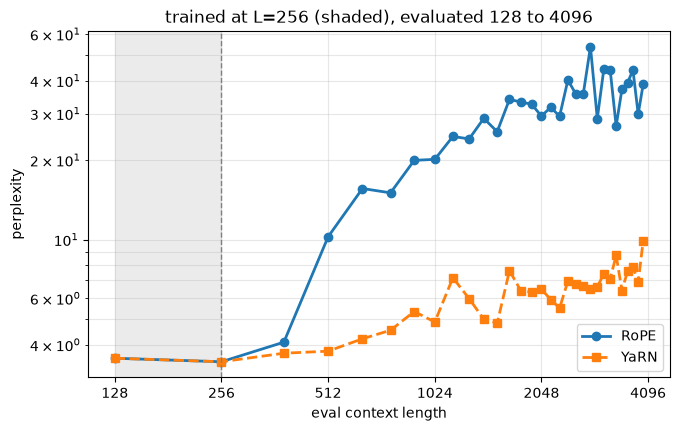

In [ ]:
# eval on both sides of the trained length, then plot
import matplotlib
try: get_ipython()
except NameError: matplotlib.use('Agg')
import matplotlib.pyplot as plt

SCORE = 64          # tokens scored at the end of each window, fixed across lengths

@torch.no_grad()
def ppl(L, yarn):
    model.eval()
    fc = precompute_freqs_cis(L, D // NH, s=(L / L_TRAIN) if yarn else 1.0, orig_len=L_TRAIN).to(dev)
    bs, reps = (4, 12) if L <= 1024 else (2, 6)      # keep O(L^2) attention in memory
    tot = 0.0
    for _ in range(reps):
        x, y = batch(val_data, bs, L)
        lg = model(x, fc)[:, -SCORE:]
        tot += F.cross_entropy(lg.reshape(-1, V), y[:, -SCORE:].reshape(-1)).item()
    model.train()
    return math.exp(tot / reps)
lens = list(range(128, 4093, 128))
rope_ppl, yarn_ppl = [], []
print(f"\n{'eval len':>9} {'s':>5} {'RoPE ppl':>10} {'YaRN ppl':>10}")
for L in lens:
    r = ppl(L, False)
    yv = ppl(L, True) if L > L_TRAIN else r          # s<=1 is a no-op, curves coincide
    rope_ppl.append(r); yarn_ppl.append(yv)
    if (L % 512 == 0):
        print(f"{L:>9} {L/L_TRAIN:>5.1f} {r:>10.2f} {yv:>10.2f}", flush=True)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.axvspan(lens[0], L_TRAIN, color='0.92', zorder=0)
ax.plot(lens, rope_ppl, 'o-', lw=2, label='RoPE')
ax.plot(lens, yarn_ppl, 's--', lw=2, label='YaRN')
ax.axvline(L_TRAIN, ls='--', c='0.5', lw=1)
ax.set_xscale('log', base=2); ax.set_yscale('log')
ax.xaxis.set_major_locator(matplotlib.ticker.LogLocator(base=2)) 
ax.xaxis.set_minor_locator(matplotlib.ticker.NullLocator())
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_xlabel('eval context length'); ax.set_ylabel(f'perplexity')
ax.set_title(f'trained at L={L_TRAIN}, evaluated 128 to 4096')
ax.grid(alpha=0.3, which='both'); ax.legend()
fig.savefig('yarn_ppl.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
""" 
Shows cleary how YaRN has lower perplexity than RoPE.
"""